<a href="https://colab.research.google.com/github/RoAr29/ecommerce-recommendation-system/blob/main/ecommerce_product_recommendation_engine.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

git add .  
git commit -m "Describe what you did today"  
git push

##Build a hybrid recommendation engine that:

Personalizes for different customer segments

Balances exploitation and exploration

Simulates revenue impact

Visualizes insights in Power BI

##System Architecture:  
Transactional Data  
        ↓   
RFM Segmentation  
        ↓  
Recommendation Models(Popularity, CF, Hybrid)  
↓  
Diversity & Bias Evaluation  
        ↓  
Exploration Strategy Layer  
        ↓  
Revenue Simulation  
        ↓  
Power BI Dashboard


## Exploratory Data Analysis Insights
- Customer revenue distribution
- Product popularity analysis
- Long tail marketplace pattern

In [ ]:
import pandas as pd

df = pd.read_excel("online_retail_II.xlsx", sheet_name=0)
df.head(10)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom
5,489434,22064,PINK DOUGHNUT TRINKET POT,24,2009-12-01 07:45:00,1.65,13085.0,United Kingdom
6,489434,21871,SAVE THE PLANET MUG,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom
7,489434,21523,FANCY FONT HOME SWEET HOME DOORMAT,10,2009-12-01 07:45:00,5.95,13085.0,United Kingdom
8,489435,22350,CAT BOWL,12,2009-12-01 07:46:00,2.55,13085.0,United Kingdom
9,489435,22349,"DOG BOWL , CHASING BALL DESIGN",12,2009-12-01 07:46:00,3.75,13085.0,United Kingdom


In [ ]:
df.shape

(525461, 8)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 525461 entries, 0 to 525460
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      525461 non-null  object        
 1   StockCode    525461 non-null  object        
 2   Description  522533 non-null  object        
 3   Quantity     525461 non-null  int64         
 4   InvoiceDate  525461 non-null  datetime64[ns]
 5   Price        525461 non-null  float64       
 6   Customer ID  417534 non-null  float64       
 7   Country      525461 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 32.1+ MB


In [ ]:
df['Customer ID'].nunique()

4383

In [ ]:
df['StockCode'].nunique()

4632

In [ ]:
df['InvoiceDate'].min(), df['InvoiceDate'].max() #shows time range of dataset

(Timestamp('2009-12-01 07:45:00'), Timestamp('2010-12-09 20:01:00'))

In [ ]:
df.isnull().sum()

,0
Invoice,0
StockCode,0
Description,2928
Quantity,0
InvoiceDate,0
Price,0
Customer ID,107927
Country,0


In [ ]:
df.describe()

,Quantity,InvoiceDate,Price,Customer ID
count,525461.000000,525461,525461.000000,417534.000000
mean,10.337667,2010-06-28 11:37:36.845017856,4.688834,15360.645478
min,-9600.000000,2009-12-01 07:45:00,-53594.360000,12346.000000
25%,1.000000,2010-03-21 12:20:00,1.250000,13983.000000
50%,3.000000,2010-07-06 09:51:00,2.100000,15311.000000
75%,10.000000,2010-10-15 12:45:00,4.210000,16799.000000
max,19152.000000,2010-12-09 20:01:00,25111.090000,18287.000000
std,107.424110,NaN,146.126914,1680.811316


In [ ]:
df = df[df['Quantity']>0]
df = df[df['Price']>0]

In [ ]:
df = df.dropna(subset=['Customer ID'])

In [ ]:
df.isnull().sum()

,0
Invoice,0
StockCode,0
Description,0
Quantity,0
InvoiceDate,0
Price,0
Customer ID,0
Country,0


A histogram shows the distribution of a numerical variable.
instead of plotting every point it groups values into ranges(bins).

<Axes: >

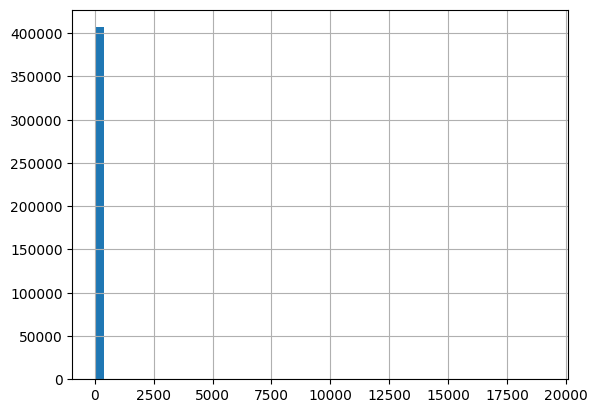

In [ ]:
df['Quantity'].hist(bins=50)

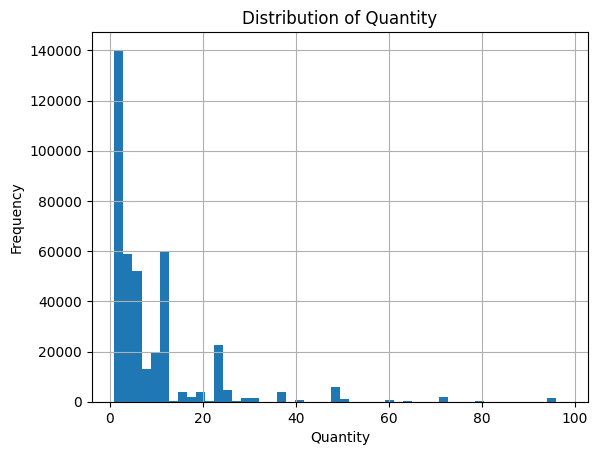

In [ ]:
import matplotlib.pyplot as plt

df[df['Quantity'] < 100]['Quantity'].hist(bins=50)
plt.title('Distribution of Quantity')
plt.xlabel('Quantity')
plt.ylabel('Frequency')
plt.show()

In [ ]:
df = df[df['Quantity'] <= 100] # here we are capping the values below 100 as a few bulk buyers influence recommendation for normal users.

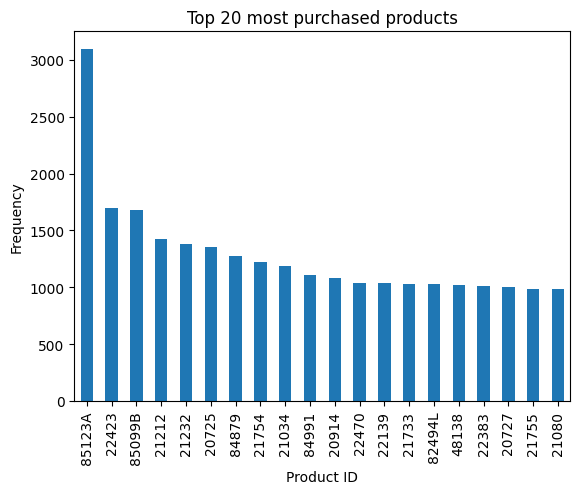

In [ ]:
top_prod = df['StockCode'].value_counts().head(20)  #this doesnt show the quant sold of product but shows how many times it appeared in invoices - no. of transactions.
# will show most frequently purchased products.
top_prod.plot(kind='bar')
plt.title('Top 20 most purchased products')
plt.xlabel('Product ID')
plt.ylabel('Frequency')
plt.show()

In [ ]:
df['Revenue'] = df['Quantity'] * df['Price']

In [ ]:
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0


Text(0, 0.5, 'Revenue')

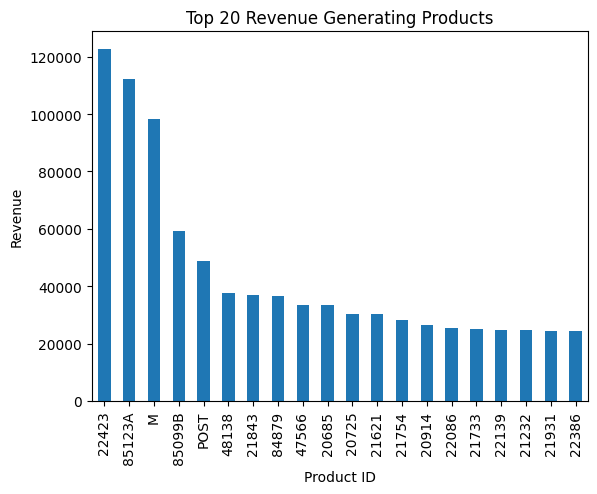

In [ ]:
product_rev = df.groupby('StockCode')['Revenue'].sum().sort_values(ascending=False).head(20)
product_rev.plot(kind='bar')
plt.title("Top 20 Revenue Generating Products")
plt.xlabel("Product ID")
plt.ylabel("Revenue")

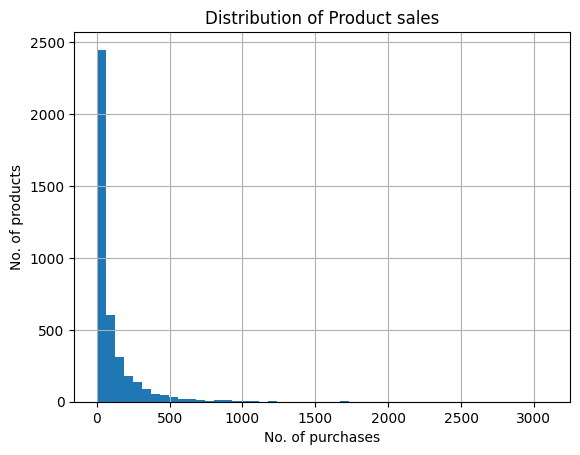

In [ ]:
product_sales = df['StockCode'].value_counts()
product_sales.hist(bins=50)
plt.title('Distribution of Product sales')
plt.xlabel('No. of purchases')
plt.ylabel('No. of products')
plt.show()

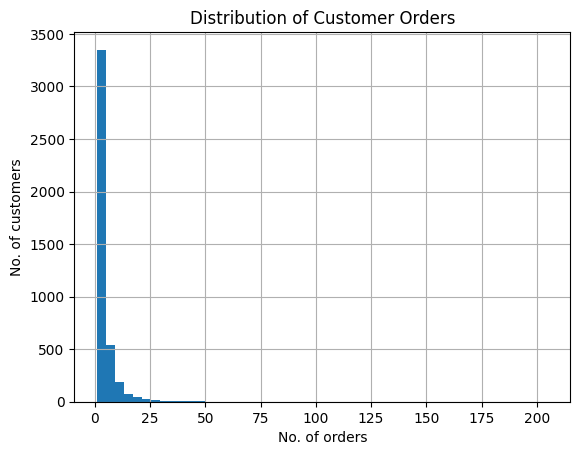

In [ ]:
customer_orders = df.groupby('Customer ID')['Invoice'].nunique() #this will group dataset by customers and each customer with their unique invoices showing
#how many orders from a single customer(later used for rfm segmentation).
customer_orders.hist(bins=50)
plt.title('Distribution of Customer Orders')
plt.xlabel('No. of orders')
plt.ylabel('No. of customers')
plt.show()

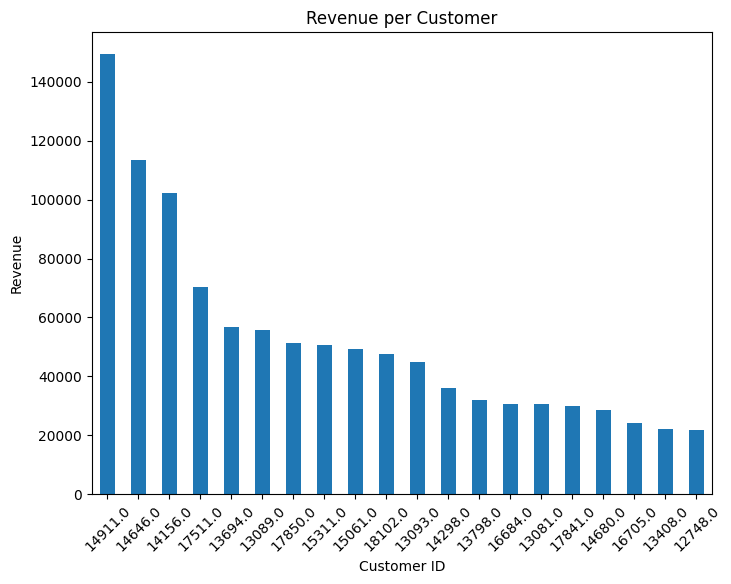

In [ ]:
cust_rev = df.groupby('Customer ID')['Revenue'].sum().sort_values(ascending=False)
cust_rev.head(20).plot(kind='bar', figsize = (8,6))
plt.xticks(rotation=45)
plt.title("Revenue per Customer")
plt.xlabel("Customer ID")
plt.ylabel("Revenue")
plt.show()

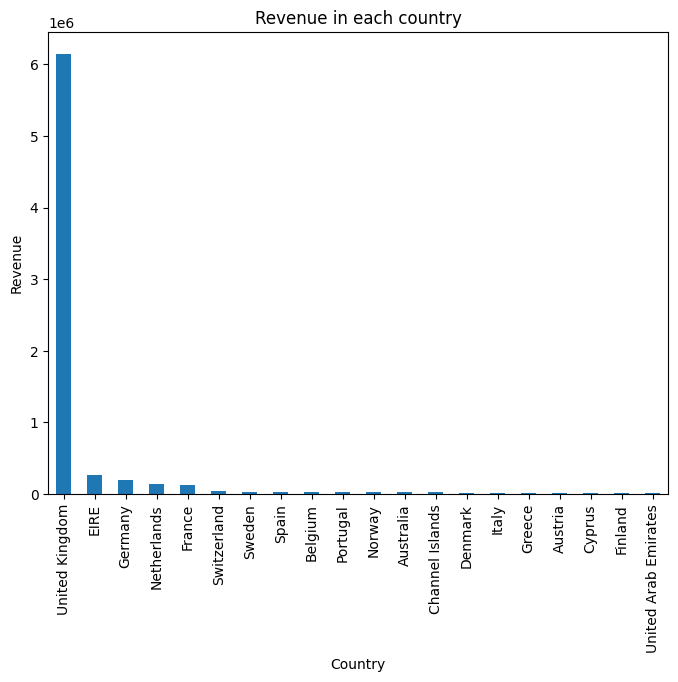

In [ ]:
cust_rev = df.groupby('Country')['Revenue'].sum().sort_values(ascending=False)
cust_rev.head(20).plot(kind='bar', figsize = (8,6))
plt.title("Revenue in each country")
plt.xlabel("Country")
plt.ylabel("Revenue")
plt.show()

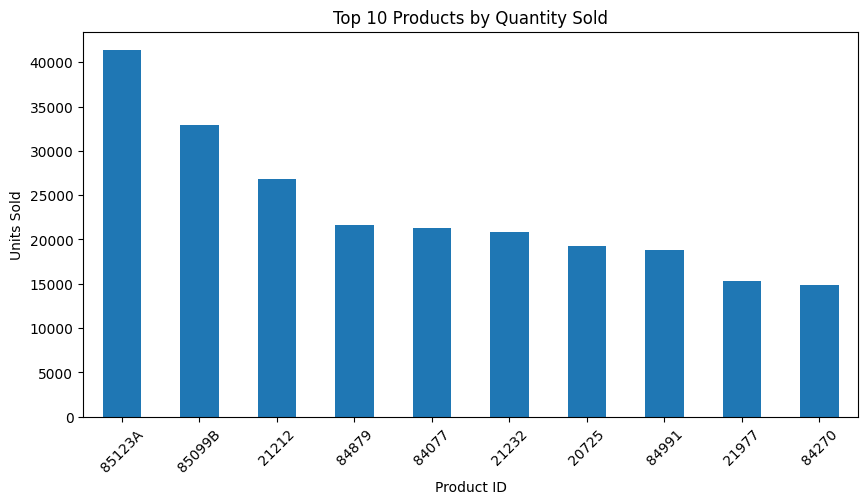

In [ ]:
top_products = df.groupby('StockCode')['Quantity'].sum().sort_values(ascending=False)

top_products.head(10).plot(kind='bar', figsize=(10,5))

plt.title("Top 10 Products by Quantity Sold")
plt.xlabel("Product ID")
plt.ylabel("Units Sold")
plt.xticks(rotation=45)
plt.show()

#RFM Customer Segmentation  
This allows us to classify customers into groups like:

VIP customers  
Loyal customers  
Occasional buyers  
Dormant customers  

Recency: How recently a customer purchased - shows if they are active   
Frequency: How frequently they purchase - shows if they are loyal  
Monetary: How much value they generate

In [ ]:
df['InvoiceDate'].max()

Timestamp('2010-12-09 20:01:00')

In [27]:
import datetime as dt

referance_date = df['InvoiceDate'].max() + dt.timedelta(days=1)